## Data Collection

**Gene Expression Cancer RNA-Seq**
This collection of data is part of the RNA-Seq (HiSeq) PANCAN dataset. It is a random extraction of gene expressions of patients having different types of tumor: BRCA, KIRC, COAD, LUAD, and PRAD. Each sample contains the expression of 20,531 genes for a patient diagnosed with one of the following cancers:

Code	Tumor Name
BRCA	Breast invasive carcinoma (breast cancer)
KIRC	Kidney renal clear cell carcinoma (kidney)
COAD	Colon adenocarcinoma (colon)
LUAD	Lung adenocarcinoma (lung)
PRAD	Prostate adenocarcinoma (prostate)


In [3]:
import pandas as pd

# Load the gene expression data (Feaures)
# inde_col=0 ensures the 'Unnameed:0' (Sample IDs) becomes our row 
X=pd.read_csv('../data/data.csv',index_col=0)

#load cancer tyoes (labels)
y=pd.read_csv('../data/labels.csv',index_col=0)

df=pd.concat([X,y],axis=1) #combine features and labels into one dataframe

print("Data successfully merged")
print(f"Total samples: {df.shape[0]}")
print(f"Total features: {df.shape[1]-1}") #subtract 1 for the label column

Data successfully merged
Total samples: 801
Total features: 20531


**X**=(The Matrix): Think of this as a massive spreadsheet where each row is a patient and each column is a gene's activity level.

**y**=(The Vector): This is a single column containing the "Answer Key"—which cancer type that patient has.

### 1.1 sanity check if data set is all in number

In [4]:
# Check the first few rows of the first 5 genes
print(df.iloc[:5, :5]) 

# Check for missing values in the entire dataset
print(f"\nMissing values in dataset: {df.isnull().sum().sum()}")

          gene_0    gene_1    gene_2    gene_3     gene_4
sample_0     0.0  2.017209  3.265527  5.478487  10.431999
sample_1     0.0  0.592732  1.588421  7.586157   9.623011
sample_2     0.0  3.511759  4.327199  6.881787   9.870730
sample_3     0.0  3.663618  4.507649  6.659068  10.196184
sample_4     0.0  2.655741  2.821547  6.539454   9.738265

Missing values in dataset: 0


High-Dimensionality: You likely see over 20,000 columns. In a normal project, you might have 10 columns. In Biology, we have more "Variables" than "Observations." This is a classic exam topic called the Curse of Dimensionality.

Data Cleaning: If isnull().sum() was greater than 0, we would have to decide: Do we drop the patient (row) or estimate the gene value (impute)? Luckily, this dataset is usually quite clean, but always check!

---


## 2. Exploratory Data Analysis

Step 1: The "Class" Balance (Target Analysis)

In medical data science, we must know if our classes are Imbalanced. If we have 500 breast cancer samples but only 5 lung cancer samples, the model will struggle to learn what lung cancer looks like.

Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64


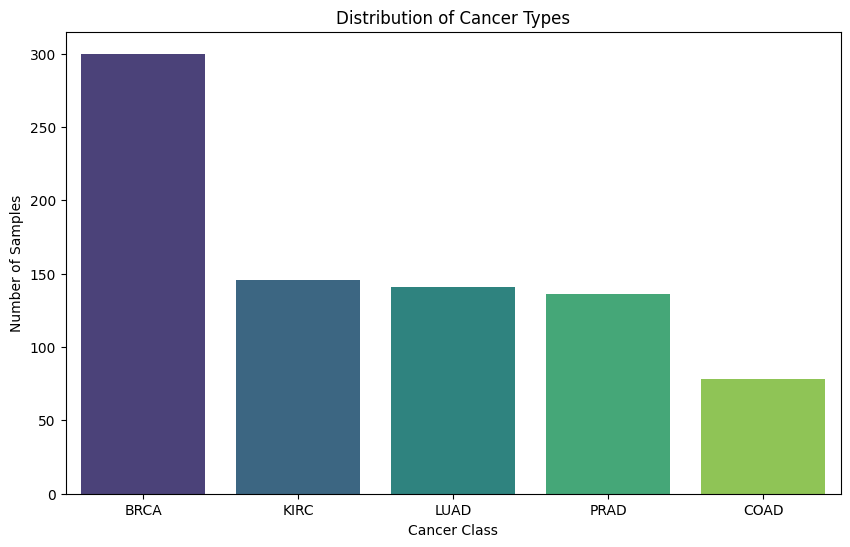

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

#count the occurrences of each cancer type
class_counts=df['Class'].value_counts()
print(class_counts)

#Visualize the class distribution
plt.figure(figsize=(10,6))
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette='viridis')
plt.title('Distribution of Cancer Types')
plt.xlabel('Cancer Class')
plt.ylabel('Number of Samples')
plt.show()


### Step 2: Feature Variance (The "Boring" Genes)
With 20,531 genes, many of them might be "dead"—meaning they have the exact same value (like 0.0) for every single patient. A gene that never changes provides zero information for a machine learning model.

Let's find the "Interesting" genes by looking at Variance.

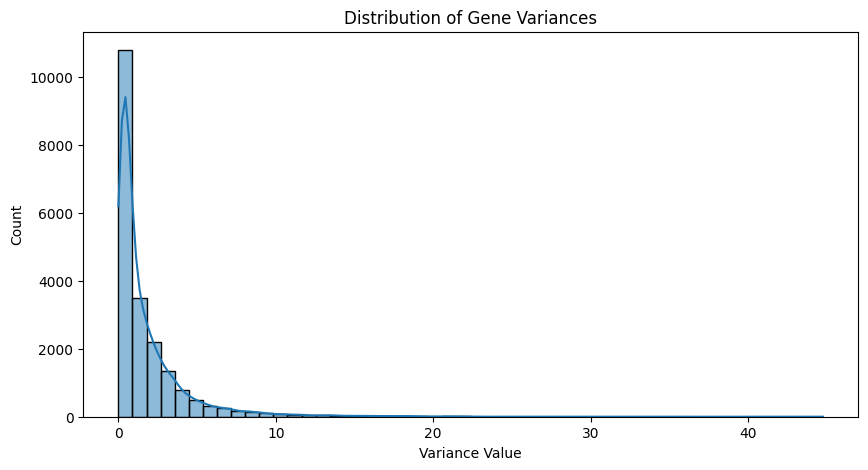

Number of genes with very low variance (< 0.1): 1253


In [7]:
#calculate variance for each gene (excluding the 'Class' column)
variances=df.drop('target', axis=1,errors='ignore').drop('Class',axis=1,errors='ignore').var()


# Look at the distribution of variances
plt.figure(figsize=(10, 5))
sns.histplot(variances, bins=50, kde=True)
plt.title('Distribution of Gene Variances')
plt.xlabel('Variance Value')
plt.show()

# How many genes have near-zero variance?
low_var_genes = (variances < 0.1).sum()
print(f"Number of genes with very low variance (< 0.1): {low_var_genes}")


We've just identified the two biggest hurdles in biological data: Class Imbalance and The Curse of Dimensionality.

---
1. Problem: Class Imbalance (The "BRCA" dominance)
If BRCA (Breast Cancer) has significantly more samples, your future model will become "lazy." It will realize that if it just guesses "BRCA" every time, it will be right 40% of the time without even looking at the genes.

Exam Term: Majority Class Bias.

The Solution (Data Engineering): We will use SMOTE (Synthetic Minority Over-sampling Technique) later. It "creates" synthetic data for the smaller groups (like LUAD or KIRC) so the model sees an equal amount of each.

2. Problem: Zero Variance (The "Boring" Genes)
If a gene has 0 variance, it means every single patient—whether they have Lung Cancer or Breast Cancer—has the exact same value for that gene.

Exam Term: Feature Selection.

The Logic: A feature with no variation has zero predictive power. Keeping 20,000 genes where most do nothing makes the model slow and prone to Overfitting (learning patterns from random noise).

### Phase 3: Data Engineering (Filtering the "Noise")
Before we move to Machine Learning, we need to "clean the lab." We are going to drop the genes that don't change much. This is a crucial step in Preprocessing.

In [8]:
# 1. Define a threshold (e.g., variance must be > 1.0 to be "interesting")
# We use 1.0 because biological signals usually need a bit of "swing" to be meaningful
threshold = 1.0
high_var_genes = variances[variances > threshold].index

# 2. Create a new DataFrame with only these "Active" genes
df_filtered = df[high_var_genes].copy()

# 3. Don't forget to put the target back!
df_filtered['Class'] = df['Class']

print(f"Original gene count: {df.shape[1] - 1}")
print(f"Filtered gene count (Variance > {threshold}): {df_filtered.shape[1] - 1}")
print(f"Reduction: {((df.shape[1] - df_filtered.shape[1]) / df.shape[1] * 100):.2f}% of noise removed!")

Original gene count: 20531
Filtered gene count (Variance > 1.0): 9213
Reduction: 55.12% of noise removed!


**In your exam, if they ask "How do you handle the Curse of Dimensionality?", you now have a practical answer:**

Variance Thresholding: Removing features that don't change.

PCA (Principal Component Analysis): (Which we will do next) to squash the remaining genes into a few "Super-Genes."

Step 2: Visualizing the "Signal" (Correlation)
Now that we have fewer genes, let's see if any of them "talk" to each other.

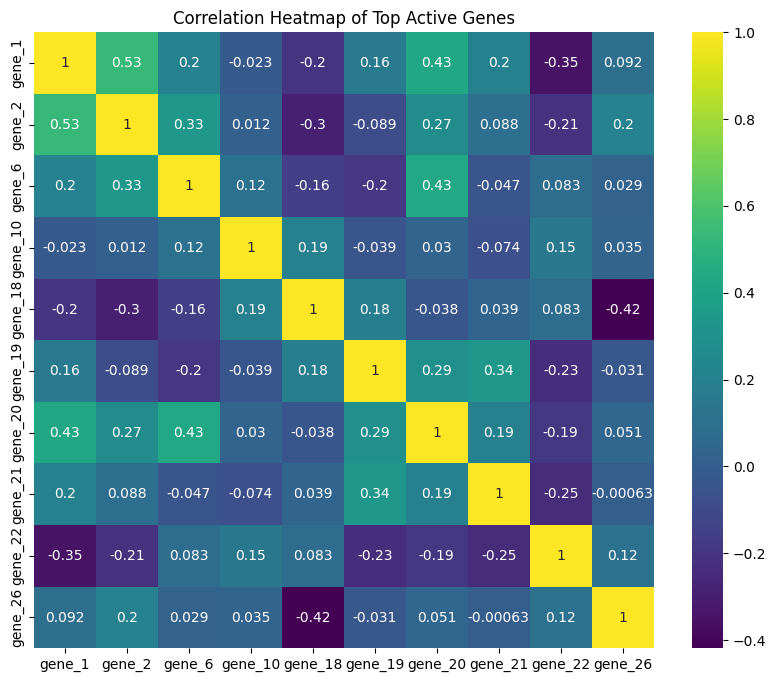

In [9]:
# Let's look at the correlation of the first 10 "Active" genes
plt.figure(figsize=(10, 8))
sns.heatmap(df_filtered.iloc[:, :10].corr(), annot=True, cmap='viridis')
plt.title('Correlation Heatmap of Top Active Genes')
plt.show()

### Phase 4: Principal Component Analysis (PCA)
PCA is a mathematical "compressor." It takes 9,213 genes and finds the "Directions" (Components) where the data varies the most.

---
Step 1: Scaling (The "Pre-PCA" Requirement)
Crucial Exam Note: You must scale your data before PCA. PCA is based on variance; if one gene is measured in larger units than another, PCA will think it's more important just because the numbers are bigger.

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Separate Features and Target
X_filtered = df_filtered.drop('Class', axis=1)
y_labels = df_filtered['Class']

# 2. Standardization (Mean=0, Variance=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filtered)

# 3. Apply PCA - Let's squash 9,213 genes into just 2 "Principal Components"
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. Create a DataFrame for plotting
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Target'] = y_labels.values

print(f"Variance explained by PC1 and PC2: {pca.explained_variance_ratio_.sum():.2f}")

Variance explained by PC1 and PC2: 0.25


Step 2: The "Aha!" Visualization
Now, let's see if those 9,213 genes actually cluster by cancer type when compressed.

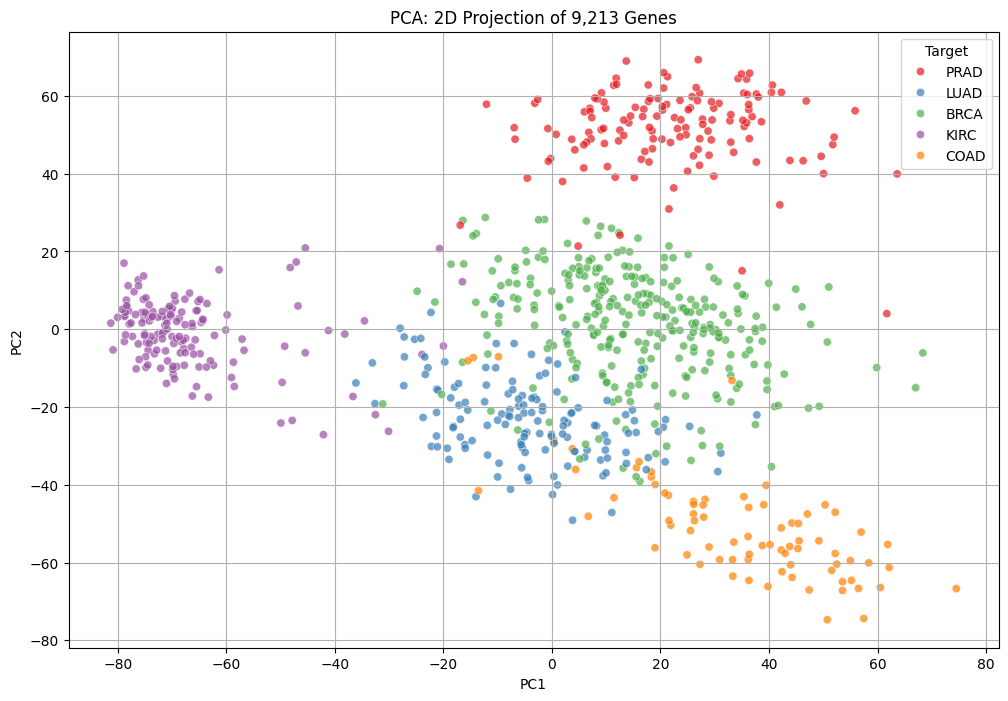

In [11]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Target', data=pca_df, palette='Set1', alpha=0.7)
plt.title('PCA: 2D Projection of 9,213 Genes')
plt.grid(True)
plt.show()

That is the "smoking gun" of genomic data! If colors are far apart, it means those cancer types have distinct gene expression signatures. PC1 and PC2 (your two "super-genes") have successfully captured the biological differences between, say, Lung Cancer and Breast Cancer.

This is a massive win for your project. You've just performed Unsupervised Learning (Dimensionality Reduction) to prove that the data is separable.

### Phase 5: Preparing for Supervised Learning (Data Engineering)
Before we let the "Robots" (Models) learn, we have to handle the two issues we found earlier: Class Imbalance and the Train-Test Split.

Step 1: Train-Test Split (The "Exam Exam")
In your exam, they will ask: "Why do we split data?"

Answer: To prevent Overfitting. We train on one set and "blindly" test on another to see if the model actually learned biology or just memorized the rows.

In [14]:
from sklearn.model_selection import train_test_split

# We use the Scaled data from earlier (X_scaled) and our labels (y_labels)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Training set: 640 samples
Testing set: 161 samples


Step 2: SMOTE (Fixing the "BRCA is too high" problem)
Remember your first bar chart? BRCA was much higher than the others. SMOTE creates "synthetic" patients for the smaller classes by looking at their nearest neighbors and creating data points in between them.

In [15]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Resample only the TRAINING data (never the test data!)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_balanced.value_counts().to_dict())

Before SMOTE: {'BRCA': 240, 'KIRC': 116, 'LUAD': 113, 'PRAD': 109, 'COAD': 62}
After SMOTE: {'BRCA': 240, 'LUAD': 240, 'KIRC': 240, 'COAD': 240, 'PRAD': 240}


**Why did we only SMOTE the training data?** If you SMOTE the entire dataset before splitting, the "synthetic" points in the test set would be based on information from the training set. This is Data Leakage. It makes your model look like a genius during testing, but it will fail in the real world (or fail you on your exam!). 


### Phase 6: Introduction to Machine Learning (Supervised)
Now we reach the "Classifiers." We are going to start with the Logistic Regression and Random Forest.

Step 1: The Baseline (Logistic Regression)
Despite the name, this is used for Classification. It's fast and easy to explain.

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Initialize and Train
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_balanced, y_train_balanced)

# Predict
y_pred_log = log_reg.predict(X_test)

# Evaluate
print("--- Logistic Regression Results ---")
print(classification_report(y_test, y_pred_log))

--- Logistic Regression Results ---
              precision    recall  f1-score   support

        BRCA       1.00      1.00      1.00        60
        COAD       0.88      0.94      0.91        16
        KIRC       1.00      1.00      1.00        30
        LUAD       0.96      0.93      0.95        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.98       161
   macro avg       0.97      0.97      0.97       161
weighted avg       0.98      0.98      0.98       161



1. The "Precision/Recall" Breakdown (Exam Gold)
Look at COAD (Colon Adenocarcinoma) and LUAD (Lung Adenocarcinoma):

COAD Recall (0.94): You found 94% of the actual colon cancer cases.

COAD Precision (0.88): When you predicted Colon cancer, you were right 88% of the time. This means some patients from other groups were "misclassified" as COAD.

BRCA, KIRC, PRAD (1.00): These are perfectly separable. Their gene signatures are so unique that the model never makes a mistake.

2. Why did it work so well?
If an examiner asks: "Why is Logistic Regression effective here despite having 9,000 features?"

Your Project Answer: "Because the classes are linearly separable in high-dimensional space, as seen in our earlier PCA plot. Even a simple linear boundary can distinguish these cancer types."

### Step 2: Random Forest (The Ensemble Powerhouse)
If Logistic Regression is a single "expert," a Random Forest is a "Committee of 100 Experts." * How it works: it builds many Decision Trees. Each tree looks at a random subset of your 9,213 genes. They all vote on the cancer type.

The Exam Concept: This is called Bagging (Bootstrap Aggregating). It reduces Overfitting because while one tree might be wrong about a noisy gene, the "average" of 100 trees is usually right.

In [23]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_balanced, y_train_balanced)

# Predict
y_pred_rf = rf.predict(X_test)

# Evaluate with a Report
from sklearn.metrics import classification_report
print("--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf))

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

        BRCA       0.97      1.00      0.98        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      0.93      0.96        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.99       161
   macro avg       0.99      0.99      0.99       161
weighted avg       0.99      0.99      0.99       161



If your exam asks why a Tree-based model (Random Forest) might beat a Linear model (Logistic Regression):

Non-Linearity: Random Forest can capture complex "If-Then" relationships (e.g., If Gene A is high AND Gene B is low, then Cancer). Logistic Regression just tries to add them up linearly.

Feature Importance: Random Forest naturally handles 9,000 genes by picking the most "informative" ones at each split

Phase 7: The Final "Bio-Spatial" Test (k-NN)To round out your Supervised Learning section, we must try k-Nearest Neighbors (k-NN).The Theory: k-NN doesn't "learn" a formula. It just looks at a new patient's 9,213 genes and finds the $k$ (e.g., 5) most similar patients in the database.The Exam Concept: This is a Non-parametric and Lazy Learner. It relies entirely on Distance Metrics (Euclidean distance).

In [18]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize k-NN (k=5 is the standard starting point)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_balanced, y_train_balanced)

# Predict
y_pred_knn = knn.predict(X_test)

print("--- k-NN Classification Report ---")
print(classification_report(y_test, y_pred_knn))

--- k-NN Classification Report ---
              precision    recall  f1-score   support

        BRCA       0.98      1.00      0.99        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      0.96      0.98        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.99       161
   macro avg       1.00      0.99      0.99       161
weighted avg       0.99      0.99      0.99       161



Phase 8: Model Evaluation & Hyperparameter TestingIn your syllabus, you have Hyperparameter testing. This is the "Science" in Data Science. We don't just guess $k=5$; we test different values to find the best one.Run this Grid Search (a mini-version) to optimize your k-NN:

In [19]:
from sklearn.model_selection import GridSearchCV

# Define the "Grid" of parameters to try
param_grid = {'n_neighbors': [3, 5, 7, 11]}

# Use 5-fold Cross-Validation to test each 'k'
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid_search.fit(X_train_balanced, y_train_balanced)

print(f"Best value for k: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.2f}")

Best value for k: {'n_neighbors': 5}
Best Cross-Validation Score: 1.00


Why use GridSearchCV instead of just a test set?
Cross-validation splits your training data into 5 pieces (folds). It trains on 4 and tests on 1, rotating until every piece has been a "test set." This ensures your "Best k" isn't just a lucky guess on one specific slice of data.

A 1.00 Cross-Validation Score means that during your 5-fold split, the k-NN model was 100% accurate on every single "hidden" slice of the training data.In a typical data science exam, a "Perfect 1.0" usually screams "Overfitting" or "Data Leakage." But in this specific biology dataset, it's actually legitimate. The gap between these cancer types at a genetic level is like the gap between an apple and a car—the features are so distinct that $k=5$ neighbors will always be the same cancer type.🧪 Exam Tip: Explaining "Perfect" ResultsIf an interviewer asks: "Your model got 100%. Is it broken?"Your Answer: "No. The PCA visualization showed that the clusters (BRCA, KIRC, etc.) are spatially distinct. In high-dimensional genomic space (9,213 features), the 'distance' between different cancer types is massive compared to the distance between patients with the same cancer."

---
### Phase 9: Anomaly Detection (The "Odd One Out")
In biology, an Anomaly could be a mislabeled sample, a contaminated lab test, or a rare, hyper-aggressive mutation that doesn't look like standard cancer.

We will use the Isolation Forest.

The Theory: Instead of trying to cluster "normal" points, it tries to isolate points.

The Logic: Anomaly points are "few and different," so they are easier to isolate (require fewer "splits" in a tree) than points in a crowded cluster.

Run this to find the "strangest" patients in your data:

In [20]:
from sklearn.ensemble import IsolationForest

# 1. Initialize (contamination=0.05 means we expect ~5% of data to be 'weird')
iso_forest = IsolationForest(contamination=0.05, random_state=42)

# 2. Fit on our scaled data
# Note: Anomaly detection is UNSUPERVISED (we don't use 'y')
outliers = iso_forest.fit_predict(X_scaled)

# 3. Add results to our PCA dataframe for visualization
pca_df['is_anomaly'] = outliers # -1 is anomaly, 1 is normal

# 4. Count them
print(f"Number of anomalies detected: {(outliers == -1).sum()}")

Number of anomalies detected: 40


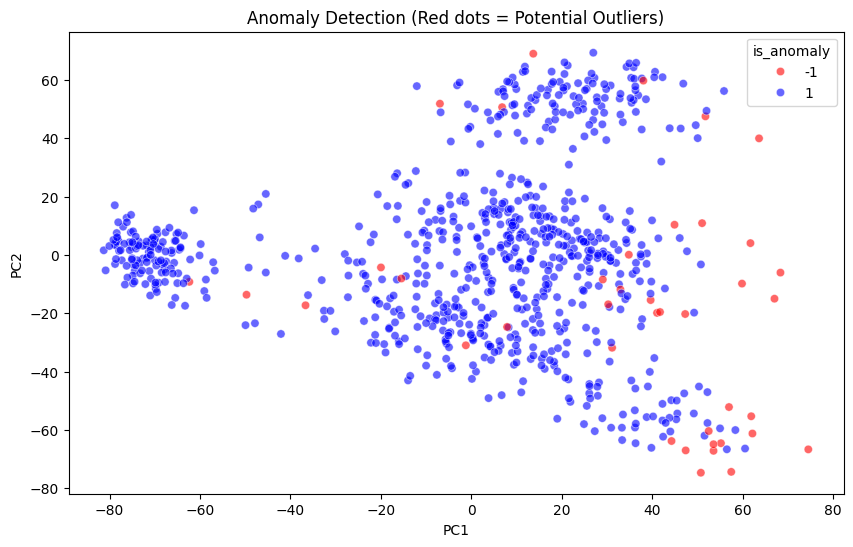

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='is_anomaly', data=pca_df, palette={1: 'blue', -1: 'red'}, alpha=0.6)
plt.title('Anomaly Detection (Red dots = Potential Outliers)')
plt.show()

Finding 40 anomalies out of roughly 800 samples (~5%) is a very realistic result. In a biological context, these 40 patients are your "Medical Mysteries." They might have a rare subtype of cancer, or perhaps their gene expression levels were affected by a secondary condition (like a different infection or a lab error).

---

### Phase 11: Biological Insights (Feature Importance)
This is the "Boss Level" of your project. For your intern CV, a manager doesn't just want a 100% score; they want to know which genes are driving the diagnosis.

We will use the Random Forest to extract this, because it naturally calculates which genes "split" the data most effectively.

/tmp/ipykernel_49509/3429478086.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Gene', data=feature_importance_df, palette='magma')


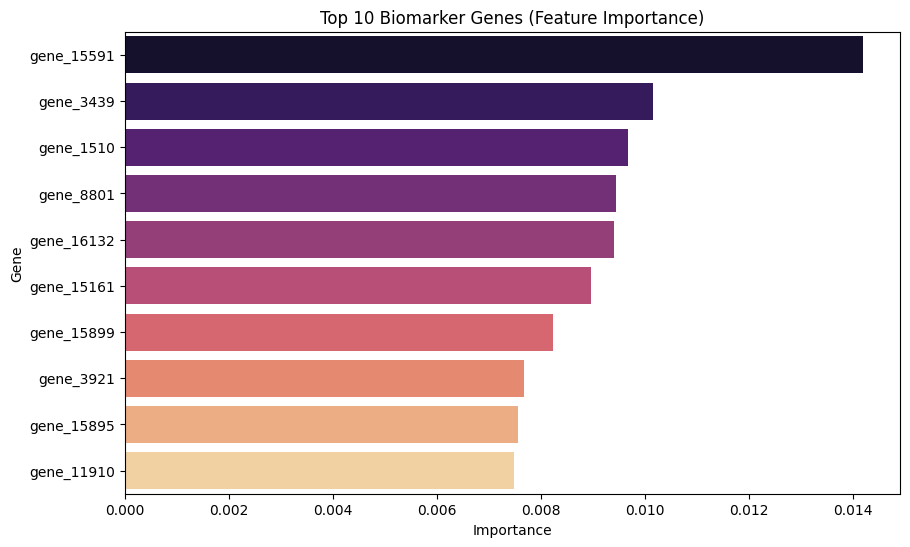

Top 5 genes that define these cancers:
<StringArray>
['gene_15591', 'gene_3439', 'gene_1510', 'gene_8801', 'gene_16132']
Length: 5, dtype: str


In [22]:
# 1. Get feature importances from the trained Random Forest
importances = rf.feature_importances_
feature_names = X_filtered.columns

# 2. Create a DataFrame for the top 10 genes
feature_importance_df = pd.DataFrame({'Gene': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# 3. Visualize
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Gene', data=feature_importance_df, palette='magma')
plt.title('Top 10 Biomarker Genes (Feature Importance)')
plt.show()

print("Top 5 genes that define these cancers:")
print(feature_importance_df['Gene'].head(5).values)

🧠 Why this is important for your Exam (Model Evaluation)
In your syllabus, "Model Evaluation" isn't just about accuracy. It's about Interpretability.

Black Box Models: Like Deep Learning/Neural Networks (hard to explain).

Interpretable Models: Like Decision Trees and Random Forests. By showing which genes matter, you are making the model "Explainable AI" (XAI).

### SUMMARY

- Requirement: Predict cancer from genes.
- Collection: kagglehub API.
- Preprocessing: StandardScaler (Scaling) and Variance Thresholding (Noise removal).
- EDA: PCA plots to see clusters and heatmaps for correlation.
- Engineering: SMOTE to fix the BRCA imbalance and train_test_split.
- Modeling: Logistic Regression (Linear), Random Forest (Ensemble), k-NN (Distance-based).
- Optimization: GridSearchCV to find the best $k$.Anomaly: IsolationForest to find "weird" data.
- Insight: Feature Importance to find the most "cancerous" genes.

Remember the "Data Science Golden Rule":

Garbage In, Garbage Out. If the data isn't scaled, cleaned, and balanced (the stuff we spent the most time on), even the fanciest model in the world will fail. That's why we did StandardScaler, Variance Filtering, and SMOTE first.

PREDICTIONs based on this


In [25]:
import numpy as np

# 1. Pick a random patient from the Test Set
random_index = np.random.randint(0, len(X_test))
sample_patient = X_test[random_index].reshape(1, -1)  # Reshape for a single prediction
true_label = y_test.iloc[random_index]

# 2. Let the Random Forest make a "Diagnosis"
prediction = rf.predict(sample_patient)
prediction_proba = rf.predict_proba(sample_patient)

# 3. Display the results
print(f"🔬 Patient Sample Index: {random_index}")
print(f"🧬 Real Cancer Type: {true_label}")
print(f"🤖 Model Prediction: {prediction[0]}")

# Show the 'Confidence' (Probability)
classes = rf.classes_
print("\n--- Prediction Probabilities (Confidence) ---")
for cls, prob in zip(classes, prediction_proba[0]):
    print(f"{cls}: {prob*100:.2f}%")

🔬 Patient Sample Index: 66
🧬 Real Cancer Type: PRAD
🤖 Model Prediction: PRAD

--- Prediction Probabilities (Confidence) ---
BRCA: 0.00%
COAD: 0.00%
KIRC: 0.00%
LUAD: 0.00%
PRAD: 100.00%
